# Quantitative Risk Management Assignment

## Import Libraries and Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, json, pathlib
import kagglehub
from pathlib import Path
import re

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report

In [2]:
path = kagglehub.dataset_download("uciml/default-of-credit-card-clients-dataset")
print("Path to dataset files:", path)

Path to dataset files: /Users/sebastianuedingslohmann/.cache/kagglehub/datasets/uciml/default-of-credit-card-clients-dataset/versions/1


## Load Data, Preprocessing, and First Look

In [3]:
# Load dataset and save as df
base = Path(path)
df = pd.read_csv(base / "UCI_Credit_Card.csv")

In [4]:
print(f'Rows: {df.shape[0]}, Columns: {df.shape[1]}')

Rows: 30000, Columns: 25


In [5]:
display(df.head())

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [6]:
df.describe()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


In [7]:
df.isnull().sum().sort_values()

ID                            0
PAY_AMT5                      0
PAY_AMT4                      0
PAY_AMT3                      0
PAY_AMT2                      0
PAY_AMT1                      0
BILL_AMT6                     0
BILL_AMT5                     0
BILL_AMT4                     0
BILL_AMT3                     0
BILL_AMT2                     0
PAY_AMT6                      0
BILL_AMT1                     0
PAY_5                         0
PAY_4                         0
PAY_3                         0
PAY_2                         0
PAY_0                         0
AGE                           0
MARRIAGE                      0
EDUCATION                     0
SEX                           0
LIMIT_BAL                     0
PAY_6                         0
default.payment.next.month    0
dtype: int64

In [8]:
# Change column name of target variable
df = df.rename(columns={"default.payment.next.month": "default"})
df.columns = [re.sub(r"[^\w]", "_", c).strip("_").lower() for c in df.columns]

# Check if target variable has only 0 and 1 values
assert set(df['default'].unique()) == {0, 1}

In [9]:
# Sex
df['sex'].value_counts(dropna=False).sort_index()

sex
1    11888
2    18112
Name: count, dtype: int64

In [10]:
# Education
df['education'].value_counts(dropna=False).sort_index()

education
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64

In [11]:
# Mapping education values 0, 5, 6 to 7 (unknown) (others remain unchanged)
edu_map = {0: 7, 5: 7, 6: 7}
df["education"] = df["education"].replace(edu_map).astype("int64")
print(df["education"].value_counts().sort_index())

education
1    10585
2    14030
3     4917
4      123
7      345
Name: count, dtype: int64


In [12]:
# Marriage
df['marriage'].value_counts(dropna=False).sort_index()

marriage
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64

In [13]:
# Payment status columns
for c in [col for col in df.columns if re.fullmatch(r"pay_[0-6]", col)]:
    print(f"\n{c}:\n{df[c].value_counts(dropna=False).sort_index()}")


pay_0:
pay_0
-2     2759
-1     5686
 0    14737
 1     3688
 2     2667
 3      322
 4       76
 5       26
 6       11
 7        9
 8       19
Name: count, dtype: int64

pay_2:
pay_2
-2     3782
-1     6050
 0    15730
 1       28
 2     3927
 3      326
 4       99
 5       25
 6       12
 7       20
 8        1
Name: count, dtype: int64

pay_3:
pay_3
-2     4085
-1     5938
 0    15764
 1        4
 2     3819
 3      240
 4       76
 5       21
 6       23
 7       27
 8        3
Name: count, dtype: int64

pay_4:
pay_4
-2     4348
-1     5687
 0    16455
 1        2
 2     3159
 3      180
 4       69
 5       35
 6        5
 7       58
 8        2
Name: count, dtype: int64

pay_5:
pay_5
-2     4546
-1     5539
 0    16947
 2     2626
 3      178
 4       84
 5       17
 6        4
 7       58
 8        1
Name: count, dtype: int64

pay_6:
pay_6
-2     4895
-1     5740
 0    16286
 2     2766
 3      184
 4       49
 5       13
 6       19
 7       46
 8        2
Name: count, dtype

In [14]:
# Bill amount columns
bill_cols = [c for c in df.columns if re.fullmatch(r"bill_amt[1-6]", c)]
df[bill_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
bill_amt1,30000.0,51223.330900,73635.860576,-165580.0,3558.75,22381.5,67091.00,964511.0
bill_amt2,30000.0,49179.075167,71173.768783,-69777.0,2984.75,21200.0,64006.25,983931.0
bill_amt3,30000.0,47013.154800,69349.387427,-157264.0,2666.25,20088.5,60164.75,1664089.0
bill_amt4,30000.0,43262.948967,64332.856134,-170000.0,2326.75,19052.0,54506.00,891586.0
bill_amt5,30000.0,40311.400967,60797.155770,-81334.0,1763.00,18104.5,50190.50,927171.0
bill_amt6,30000.0,38871.760400,59554.107537,-339603.0,1256.00,17071.0,49198.25,961664.0


In [15]:
# Pay amount columns
pay_amt_cols = [c for c in df.columns if re.fullmatch(r"pay_amt[1-6]", c)]
df[pay_amt_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
pay_amt1,30000.0,5663.580500,16563.280354,0.0,1000.00,2100.0,5006.00,873552.0
pay_amt2,30000.0,5921.163500,23040.870402,0.0,833.00,2009.0,5000.00,1684259.0
pay_amt3,30000.0,5225.681500,17606.961470,0.0,390.00,1800.0,4505.00,896040.0
pay_amt4,30000.0,4826.076867,15666.159744,0.0,296.00,1500.0,4013.25,621000.0
pay_amt5,30000.0,4799.387633,15278.305679,0.0,252.50,1500.0,4031.50,426529.0
pay_amt6,30000.0,5215.502567,17777.465775,0.0,117.75,1500.0,4000.00,528666.0


In [16]:
# Check if target variable has only 0 and 1 values
assert set(df['default'].unique()) == {0, 1}

In [17]:
sex_dummies = pd.get_dummies(df["sex"], prefix="sex")
df = pd.concat([df, sex_dummies], axis=1)

In [18]:
marriage_dummies = pd.get_dummies(df["marriage"], prefix="marriage")
df = pd.concat([df, marriage_dummies], axis=1)

In [19]:
edu_dummies = pd.get_dummies(df["education"], prefix="education")
df = pd.concat([df, edu_dummies], axis=1)

In [20]:
# Drop original categorical columns as well as one dummy variable from each to avoid multicollinearity
df = df.drop(columns=['sex', 'sex_2', 'education', 'education_7', 'marriage', 'marriage_3'])
df.head()


,id,limit_bal,age,pay_0,pay_2,pay_3,pay_4,pay_5,pay_6,bill_amt1,...,pay_amt6,default,sex_1,marriage_0,marriage_1,marriage_2,education_1,education_2,education_3,education_4
0,1,20000.0,24,2,2,-1,-1,-2,-2,3913.0,...,0.0,1,False,False,True,False,False,True,False,False
1,2,120000.0,26,-1,2,0,0,0,2,2682.0,...,2000.0,1,False,False,False,True,False,True,False,False
2,3,90000.0,34,0,0,0,0,0,0,29239.0,...,5000.0,0,False,False,False,True,False,True,False,False
3,4,50000.0,37,0,0,0,0,0,0,46990.0,...,1000.0,0,False,False,True,False,False,True,False,False
4,5,50000.0,57,-1,0,-1,0,0,0,8617.0,...,679.0,0,True,False,True,False,False,True,False,False


## Feature Engineering

In [39]:
pay_cols = ['pay_0', 'pay_2', 'pay_3', 'pay_4', 'pay_5', 'pay_6']

df['max_late_payment'] = df[pay_cols].max(axis=1)
df['num_late_payments'] = (df[pay_cols] > 0).sum(axis=1)
df['recent_late_payment'] = (df['pay_0'] > 0).astype(int)
df['delay_trend_overall'] = df['pay_0'].clip(lower=0) - df['pay_6'].clip(lower=0)
df['num_fully_paid'] = (df[pay_cols] == -1).sum(axis=1)
df['num_inactive_months'] = (df[pay_cols] == -2).sum(axis=1)

In [40]:
bill_cols = ['bill_amt1', 'bill_amt2', 'bill_amt3', 'bill_amt4', 'bill_amt5', 'bill_amt6']

df['bill_mean'] = df[bill_cols].mean(axis=1)
df['bill_std'] = df[bill_cols].std(axis=1)
df['bill_trend'] = df['bill_amt1'] - df['bill_amt6']


## Exploratory Data Analysis

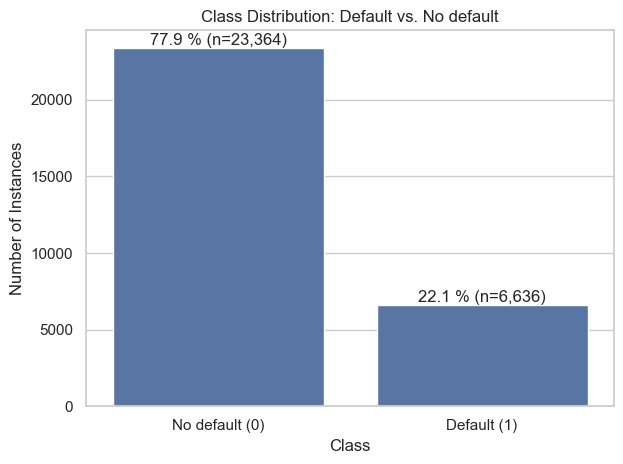

In [23]:
# Visualize the class imbalance in a barplot
sns.set_theme(style="whitegrid")

counts = df["default"].value_counts().sort_index()
pcts   = (df["default"].value_counts(normalize=True)
         .sort_index()
         .mul(100).round(1))

labels = ["No default (0)", "Default (1)"]

ax = sns.barplot(x=labels, y=counts.values)
ax.set_xlabel("Class")
ax.set_ylabel("Number of Instances")
ax.set_title("Class Distribution: Default vs. No default")

for i, (n, p) in enumerate(zip(counts.values, pcts.values)):
    ax.text(i, n, f"{p} % (n={n:,})", ha="center", va="bottom")

plt.tight_layout()
plt.show()

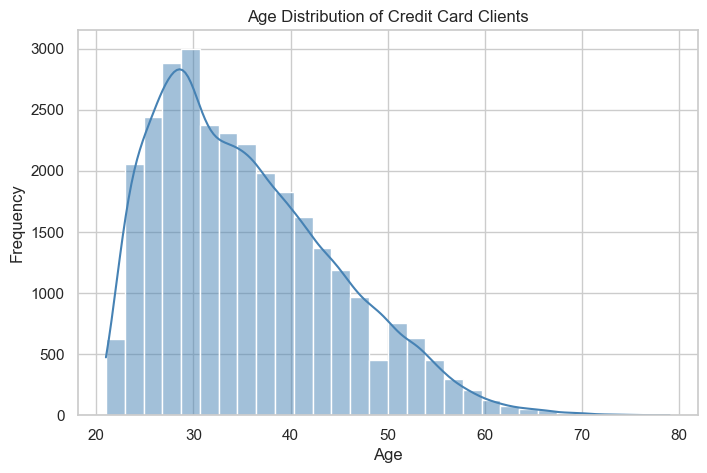

In [49]:
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=30, kde=True, color='steelblue')
plt.title('Age Distribution of Credit Card Clients')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

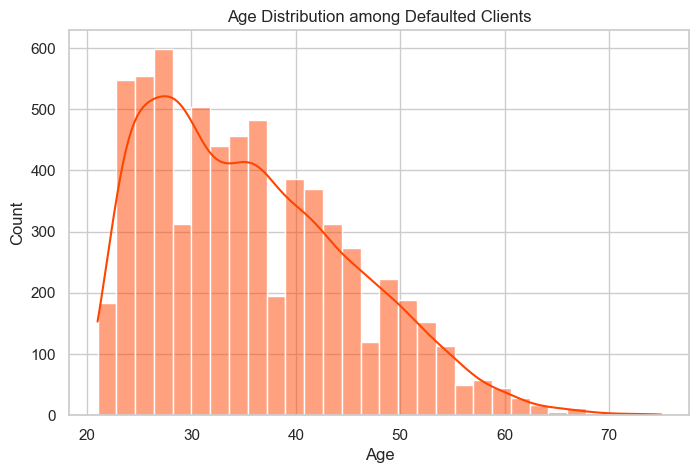

In [51]:
df_default = df[df["default"] == 1]

plt.figure(figsize=(8,5))
sns.histplot(
    data=df_default,
    x="age",
    bins=30,
    kde=True,
    color="orangered",
)
plt.title("Age Distribution among Defaulted Clients")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

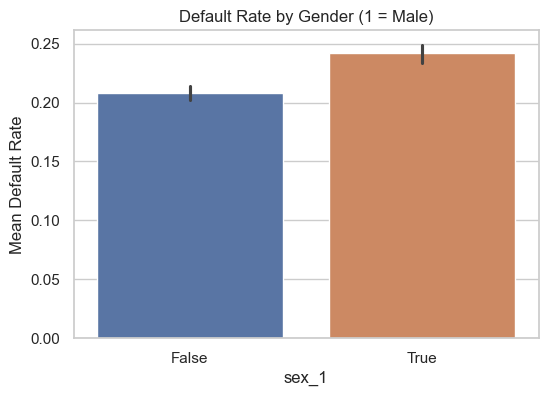

In [48]:
plt.figure(figsize=(6,4))
sns.barplot(data=df, x="sex_1", y="default", estimator=lambda x: np.mean(x), hue = "sex_1", legend = False)
plt.title("Default Rate by Gender (1 = Male)")
plt.ylabel("Mean Default Rate")
plt.show()

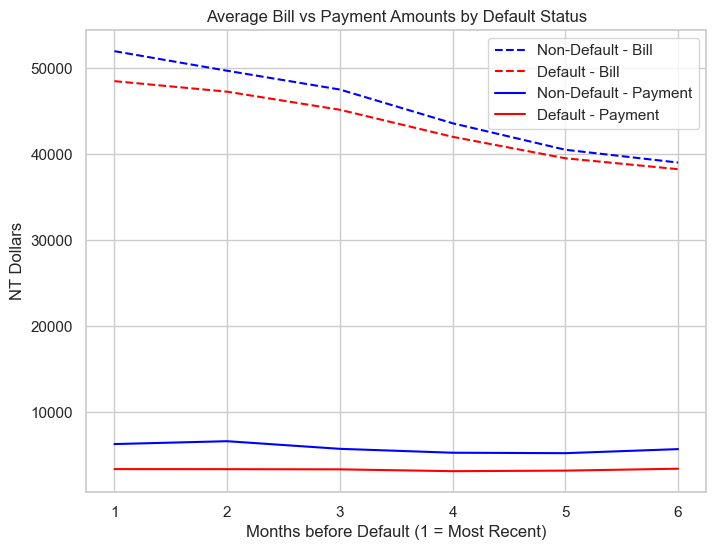

In [56]:
months = np.arange(1, 7)

plt.figure(figsize=(8,6))

# Bill amounts
plt.plot(months, mean_bill.loc[bill_cols, 0], '--', label="Non-Default - Bill", color='blue')
plt.plot(months, mean_bill.loc[bill_cols, 1], '--', label="Default - Bill", color='red')

# Payment amounts
plt.plot(months, mean_pay.loc[pay_cols, 0], '-', label="Non-Default - Payment", color='blue')
plt.plot(months, mean_pay.loc[pay_cols, 1], '-', label="Default - Payment", color='red')

plt.title("Average Bill vs Payment Amounts by Default Status")
plt.xlabel("Months before Default (1 = Most Recent)")
plt.ylabel("NT Dollars")
plt.legend()
plt.show()

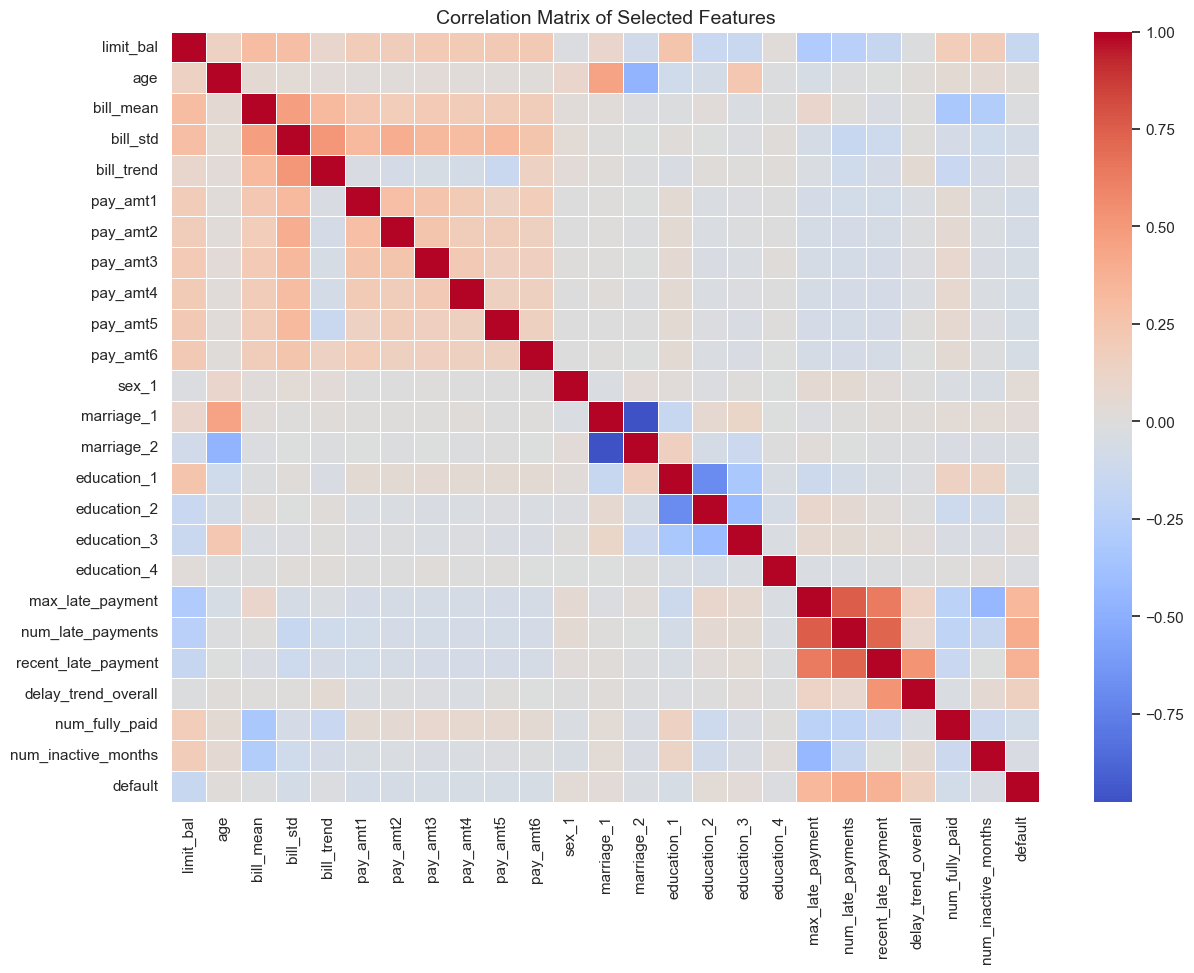

In [43]:
feature_cols = ['limit_bal', 'age', 'bill_mean', 'bill_std', 'bill_trend', 'pay_amt1', 'pay_amt2', 'pay_amt3', 'pay_amt4', 'pay_amt5', 'pay_amt6', 'sex_1', 'marriage_1', 'marriage_2', 'education_1', 'education_2', 'education_3', 'education_4', 'max_late_payment', 'num_late_payments', 'recent_late_payment', 'delay_trend_overall', 'num_fully_paid', 'num_inactive_months']
corr_features = feature_cols + ["default"]

corr = df[corr_features].corr(numeric_only=True)

plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Correlation Matrix of Selected Features", fontsize=14)
plt.show()

Leaving features even if there is some correlation, will be taken care of by L2 regularisation.

In [66]:
y = df["default"].astype("int64")
X = df.drop(columns=["default"])

In [68]:
dummy_prefixes = ("sex_cat_","education_cat_","marriage_cat_","paid_in_full_")
cols_to_scale = [c for c in X.columns if not c.startswith(dummy_prefixes)]

In [67]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state=42, stratify = y)

In [70]:
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

In [71]:
X_train_scaled[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test_scaled[cols_to_scale]  = scaler.transform(X_test[cols_to_scale])

In [72]:
model = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")
model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [73]:
proba = model.predict_proba(X_test_scaled)[:, 1]
pred  = (proba >= 0.5).astype(int)

In [74]:
print("ROC-AUC:", round(roc_auc_score(y_test, proba), 4))
print("\nConfusion matrix:\n", confusion_matrix(y_test, pred))
print("\nReport:\n", classification_report(y_test, pred, digits=3))

ROC-AUC: 0.7522

Confusion matrix:
 [[3923  750]
 [ 589  738]]

Report:
               precision    recall  f1-score   support

           0      0.869     0.840     0.854      4673
           1      0.496     0.556     0.524      1327

    accuracy                          0.777      6000
   macro avg      0.683     0.698     0.689      6000
weighted avg      0.787     0.777     0.781      6000

